# 1️⃣ Problem + Data Overview 

In [140]:
import pandas as pd

df = pd.read_csv("cs-training.csv")
print(df.head())
print(df.shape)
print(df.info())
df.describe()

   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                   

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


# 2️⃣ Target Variable Analysis

In [141]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

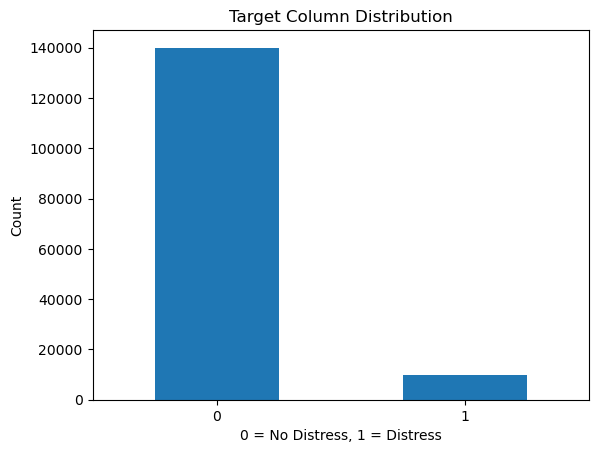

In [142]:
import matplotlib.pyplot as plt
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar')
plt.title('Target Column Distribution')
plt.xlabel('0 = No Distress, 1 = Distress')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show

# 3️⃣ EDA

## Financial variables

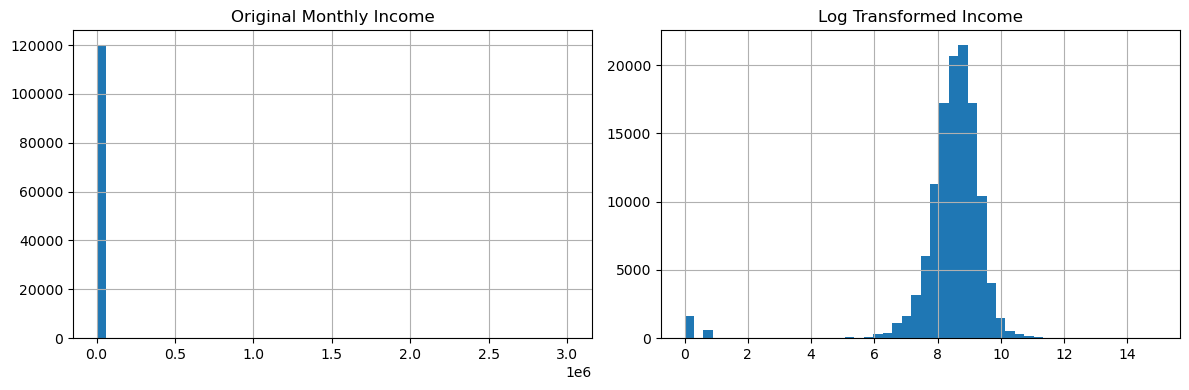

In [143]:
import matplotlib.pyplot as plt
import numpy as np
df['log_income'] = np.log1p(df['MonthlyIncome'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['MonthlyIncome'].hist(bins=50, ax=axes[0])
axes[0].set_title("Original Monthly Income")

df['log_income'].hist(bins=50, ax=axes[1])
axes[1].set_title("Log Transformed Income")

plt.tight_layout()
plt.show()

## Personal

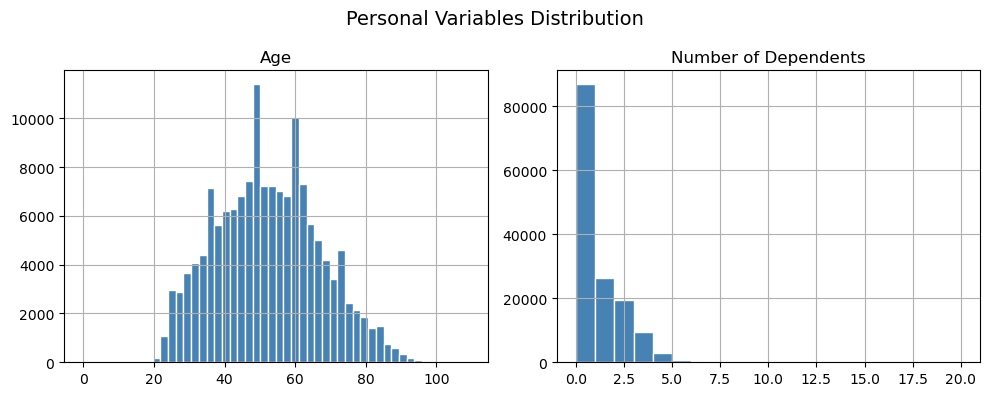

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Personal Variables Distribution', fontsize=14)

df['age'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age')

df['NumberOfDependents'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Number of Dependents')

plt.tight_layout()
plt.show()

## Credit history

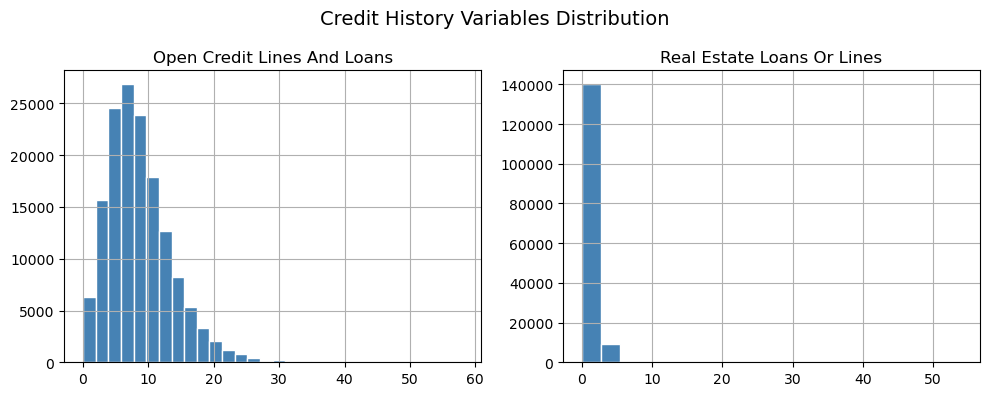

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Credit History Variables Distribution', fontsize=14)

df['NumberOfOpenCreditLinesAndLoans'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Open Credit Lines And Loans')

df['NumberRealEstateLoansOrLines'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Real Estate Loans Or Lines')

plt.tight_layout()
plt.show()

# 4️⃣ Data Cleaning

## Missing values

In [146]:
df.isnull().sum()

df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['log_income'] = df['log_income'].fillna(df['log_income'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

## Outliers

In [147]:
(df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()

np.int64(3321)

In [148]:
df['RevolvingUtilizationOfUnsecuredLines'].quantile([0.25, 0.5, 0.75, 0.90, 0.99])

0.25    0.029867
0.50    0.154181
0.75    0.559046
0.90    0.981278
0.99    1.092956
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [149]:
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

In [150]:
(df['DebtRatio']>1).sum()

np.int64(35137)

In [151]:
df['DebtRatio'].quantile([0.25, 0.5, 0.75, 0.90, 0.99])

0.25       0.175074
0.50       0.366508
0.75       0.868254
0.90    1267.000000
0.99    4979.040000
Name: DebtRatio, dtype: float64

In [152]:
cap = df['DebtRatio'].quantile(0.99)
df['DebtRatio'] = df['DebtRatio'].clip(upper=cap)

## Impossible values

In [153]:
(df['age'] == 0).sum()

np.int64(1)

In [154]:
median_age = df['age'].median()
median_age = df['age'].median()
df.loc[df['age']== 0 , 'age'] = median_age
df['age'].min()

21

In [155]:
cols = ['NumberOfTime30-59DaysPastDueNotWorse', 
        'NumberOfTimes90DaysLate', 
        'NumberOfTime60-89DaysPastDueNotWorse']

for col in cols:
    print(f"{col}: 96s = {(df[col] == 96).sum()}, 98s = {(df[col] == 98).sum()}")

NumberOfTime30-59DaysPastDueNotWorse: 96s = 5, 98s = 264
NumberOfTimes90DaysLate: 96s = 5, 98s = 264
NumberOfTime60-89DaysPastDueNotWorse: 96s = 5, 98s = 264


In [156]:
for col in cols:
    median_val = df[col].median()
    df.loc[df[col] == 96, col] = median_val
    df.loc[df[col] == 98, col] = median_val

# 5️⃣ Correlation Heatmap

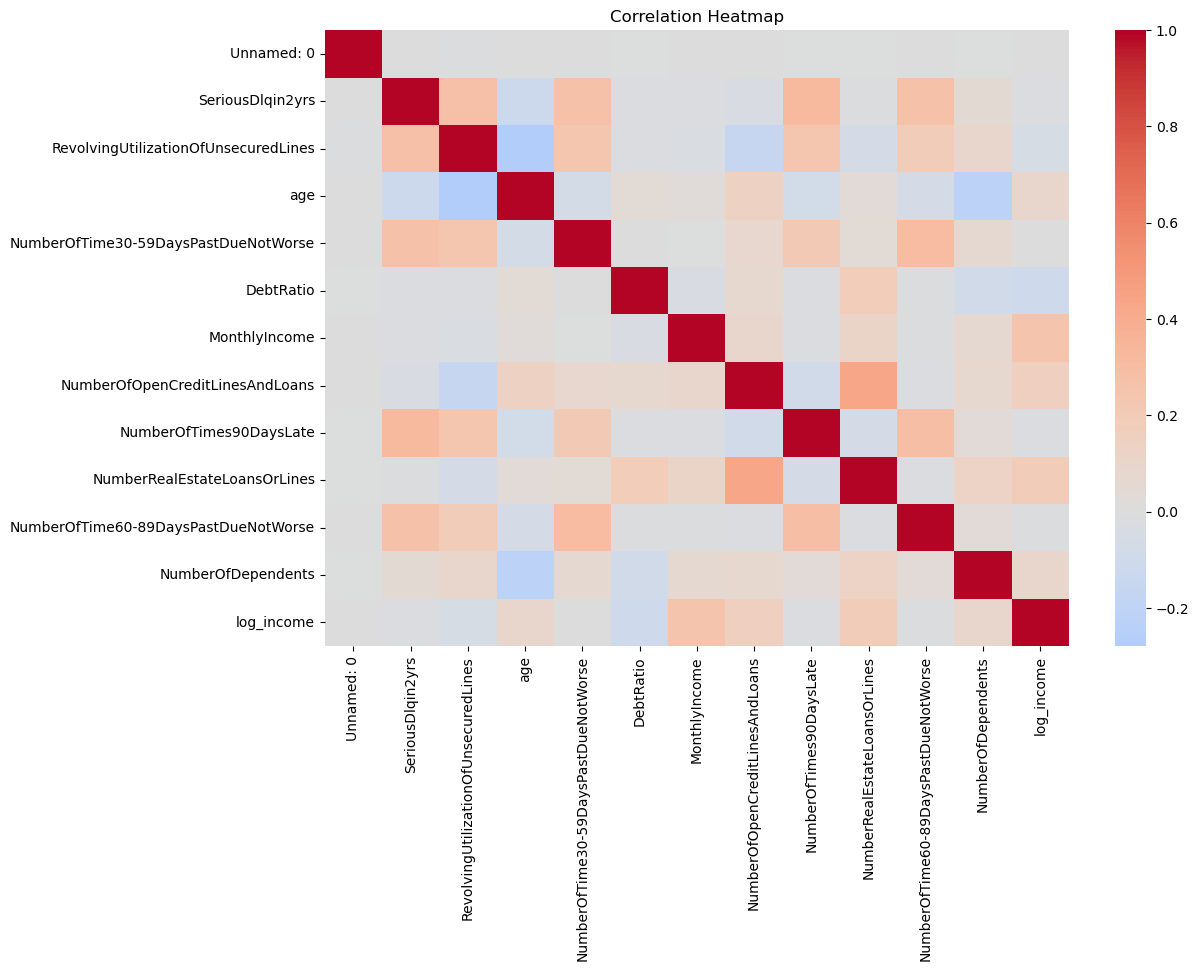

In [157]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# 6️⃣ Preprocessing

In [158]:
X = df.drop(columns=['SeriousDlqin2yrs', 'Unnamed: 0', 'MonthlyIncome' ])
y = df['SeriousDlqin2yrs']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7️⃣ Class Imbalance

In [160]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 8️⃣ MODELING

## Logistic Regression

In [161]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]


## Random Forest

In [164]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,
                            random_state=42)

rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]



## XGBoost

In [165]:
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100,
                    eval_metric='logloss',
                    random_state=42)

xgb.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]

# 9️⃣ FINAL EVALUATION

In [139]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score


results = pd.DataFrame({

    'Model': ['Logistic Regression',
              'Random Forest',
              'XGBoost'],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results.round(3)

,Model,ROC-AUC,Precision,Recall,F1-Score
0,Logistic Regression,0.852,0.206,0.748,0.323
1,Random Forest,0.830,0.334,0.424,0.374
2,XGBoost,0.844,0.393,0.366,0.379
